[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/03-classical-ml/04_model_evaluation.ipynb)

# What the Score Is Not Telling You

**Session 11 · no homework grades this · the project depends on it**

Every number in this notebook is computed correctly. Most of them are still
wrong answers to the question somebody asked, and the reason is always one of
three things: the metric does not match the decision, the splitter does not
match the data, or the test set has already been spent.

One dataset, one model, and the four ways of measuring it that disagree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(13)

X, y = make_classification(n_samples=6000, n_features=12, n_informative=6,
                           weights=[0.93, 0.07], flip_y=0.005, class_sep=1.8,
                           random_state=13)

# Three splits, not two: the validation split is where every choice gets made.
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_rest, y_rest, test_size=0.25, random_state=0, stratify=y_rest)

for name, part in (("train", y_train), ("validation", y_valid), ("test", y_test)):
    print(f"{name:<11} n = {len(part):>4}   positives = {part.mean():.1%}")

train       n = 3600   positives = 7.3%
validation  n = 1200   positives = 7.2%
test        n = 1200   positives = 7.2%


## 1. Six metrics that do not agree

The dummy classifier predicts the majority class and nothing else. Read what
each metric says about it.

In [2]:
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             precision_score, recall_score, roc_auc_score)

models = {
    "always negative": DummyClassifier(strategy="most_frequent"),
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "random forest": RandomForestClassifier(n_estimators=200, random_state=0),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    score = (model.predict_proba(X_valid)[:, 1]
             if hasattr(model, "predict_proba") else np.zeros(len(y_valid)))
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_valid, pred),
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred),
        "f1": f1_score(y_valid, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, score),
        "avg_precision": average_precision_score(y_valid, score),
    })

print(pd.DataFrame(rows).set_index("model").round(3).to_string())

                 accuracy  precision  recall     f1  roc_auc  avg_precision
model                                                                      
always negative     0.928      0.000   0.000  0.000    0.500          0.072
logistic            0.942      0.655   0.414  0.507    0.948          0.524
random forest       0.989      1.000   0.851  0.919    0.993          0.975


The do-nothing model scores over 0.9 on accuracy and 0.0 on everything that
matters. That is the accuracy trap in one row, and it is why the first question
about any classification result is *what is the base rate?*

Look at the logistic row: ROC-AUC 0.95, average precision 0.52. Both are correct
and they are not in conflict — on a 7% positive rate they answer different
questions. ROC-AUC rewards ranking negatives below positives, and there are
thirteen negatives per positive to get right, so it stays flattering; average
precision asks how much of what you flagged was worth flagging, and it does not.
Note too that the dummy model's ROC-AUC is exactly 0.5 while its average
precision is 0.072 — the base rate. **On a rare-event problem, average precision
is the honest headline.**

## 2. Probabilities you can act on

A model can rank perfectly and still be badly calibrated: if it says 0.9 for
cases that happen 40% of the time, then "0.9" cannot enter a cost calculation.
The reliability diagram is the check.

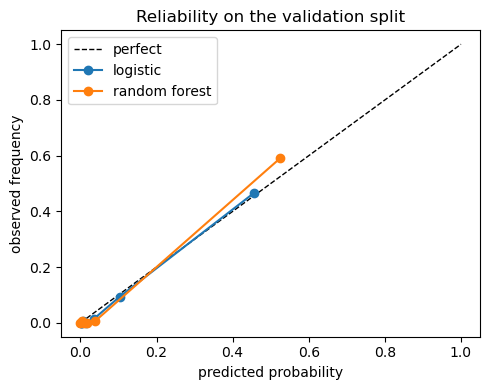

logistic       Brier score 0.0433 (lower is better)
random forest  Brier score 0.0100 (lower is better)


In [3]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name in ("logistic", "random forest"):
    p = models[name].predict_proba(X_valid)[:, 1]
    frac, mean_pred = calibration_curve(y_valid, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac, "o-", label=name)
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability on the validation split"); ax.legend()
plt.tight_layout(); plt.show()

from sklearn.metrics import brier_score_loss
for name in ("logistic", "random forest"):
    p = models[name].predict_proba(X_valid)[:, 1]
    print(f"{name:<14} Brier score {brier_score_loss(y_valid, p):.4f} (lower is better)")

Points below the diagonal mean the model is over-confident in that band; above
means under-confident. A model can be miscalibrated and still be the best
ranker you have — which is exactly why the two properties get measured
separately.

## 3. Choosing the threshold, on the right data

The threshold is chosen to maximise something you care about. Here: the largest
recall that keeps precision at or above 0.5, because below that the review queue
is mostly false alarms.

In [4]:
from sklearn.metrics import precision_recall_curve

model = models["logistic"]
p_valid = model.predict_proba(X_valid)[:, 1]
prec, rec, thr = precision_recall_curve(y_valid, p_valid)

TARGET_PRECISION = 0.50
usable = prec[:-1] >= TARGET_PRECISION

if usable.any():
    chosen = float(thr[usable][np.argmax(rec[:-1][usable])])
else:
    # The objective is not always reachable. Say so rather than silently
    # falling back to something else.
    chosen = float(thr[np.argmax(prec[:-1])])
    print(f"no threshold reaches precision {TARGET_PRECISION}; using the best available")

pred_valid = (p_valid >= chosen).astype(int)
print(f"threshold chosen on VALIDATION: {chosen:.3f}")
print(f"  validation precision {precision_score(y_valid, pred_valid, zero_division=0):.3f}"
      f"  recall {recall_score(y_valid, pred_valid):.3f}"
      f"  flagged {pred_valid.sum()} of {len(pred_valid)}")

default = (p_valid >= 0.5).astype(int)
print(f"the untouched default of 0.5  : precision "
      f"{precision_score(y_valid, default, zero_division=0):.3f}"
      f"  recall {recall_score(y_valid, default):.3f}"
      f"  flagged {default.sum()} of {len(default)}")

threshold chosen on VALIDATION: 0.193
  validation precision 0.500  recall 0.805  flagged 140 of 1200
the untouched default of 0.5  : precision 0.655  recall 0.414  flagged 55 of 1200


## 4. The splitter is a question about the data

Everything so far assumed rows are independent. They usually are not. Below,
each patient contributes several rows — repeated visits — and the target is
mostly a property of the patient.

In [5]:
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score

n_patients, visits_each = 400, 5
patient = np.repeat(np.arange(n_patients), visits_each)

# Whether a patient is a case is decided by something the features never record.
latent = rng.normal(size=n_patients)
labels = (latent > 0.3).astype(int)[patient]

# Three columns that identify the patient (a fingerprint: stable across their
# visits, meaningless across patients) and one column carrying a weak real signal.
fingerprint = rng.normal(size=(n_patients, 3))[patient] + rng.normal(0, 0.05, (len(patient), 3))
measured = (latent[patient] * 0.45 + rng.normal(0, 1.0, len(patient))).reshape(-1, 1)

features = np.hstack([fingerprint, measured])
print("rows:", len(patient), " patients:", n_patients,
      " visits each:", visits_each, " positive rate:", round(labels.mean(), 3))
print("the label is constant within a patient:",
      bool(pd.Series(labels).groupby(patient).nunique().eq(1).all()))

rows: 2000  patients: 400  visits each: 5  positive rate: 0.395
the label is constant within a patient: True


In [6]:
forest = RandomForestClassifier(n_estimators=200, random_state=0)

by_row = cross_val_score(forest, features, labels,
                         cv=StratifiedKFold(5, shuffle=True, random_state=0),
                         scoring="roc_auc")
by_patient = cross_val_score(forest, features, labels,
                             cv=GroupKFold(5), groups=patient,
                             scoring="roc_auc")

print(f"StratifiedKFold (rows split at random): {by_row.mean():.4f}  +/- {by_row.std():.4f}")
print(f"GroupKFold (whole patients held out)  : {by_patient.mean():.4f}  +/- {by_patient.std():.4f}")
print(f"difference                            : {by_row.mean() - by_patient.mean():+.4f}")

StratifiedKFold (rows split at random): 0.8394  +/- 0.0292
GroupKFold (whole patients held out)  : 0.6285  +/- 0.0552
difference                            : +0.2109


Twenty points of AUC, and no bug anywhere. The random split leaves four of a
patient's five visits in training, so the forest learns the fingerprint of each
training patient and reads their label off it — a lookup table, not a model. The
group split holds whole patients out, and the lookup table is worthless, leaving
only the weak signal in `measured`, which is all the model ever really had.

The group number is the question anybody actually has: *will this work on a
patient we have never seen?*

Neither number is a mistake in arithmetic. The first one answers a question
nobody asked. **Choosing the splitter is choosing the question** — and the
choice is dictated by the structure of the data, not by convenience:

| Structure | Splitter |
|---|---|
| independent rows | `KFold` / `StratifiedKFold` |
| repeated measures, patients, users, sites | `GroupKFold` |
| anything with time | `TimeSeriesSplit` — never shuffle |
| rare classes | stratify, and check the fold positive counts |

## 5. Spending the test set

Every choice above — model, threshold, splitter — was made on training and
validation data. Now, once:

In [7]:
p_test = model.predict_proba(X_test)[:, 1]
pred_test = (p_test >= chosen).astype(int)

print(f"threshold carried over from validation: {chosen:.3f}\n")
print(f"test precision      {precision_score(y_test, pred_test, zero_division=0):.3f}")
print(f"test recall         {recall_score(y_test, pred_test):.3f}")
print(f"test average precision {average_precision_score(y_test, p_test):.3f}")
print(f"test ROC-AUC        {roc_auc_score(y_test, p_test):.3f}")
print("\nfor comparison, on validation: precision "
      f"{precision_score(y_valid, pred_valid, zero_division=0):.3f}"
      f"  recall {recall_score(y_valid, pred_valid):.3f}")

threshold carried over from validation: 0.193

test precision      0.483
test recall         0.793
test average precision 0.588
test ROC-AUC        0.952

for comparison, on validation: precision 0.500  recall 0.805


The test numbers are close to the validation ones, which is what you hope for
and not what you assume. A large drop would mean the threshold was tuned to
noise in the validation split; a large rise would mean luck.

If you now go back and pick a different threshold because you did not like these
numbers, the test set is gone — it has become a second validation set, and the
next number you report is optimistic by an amount nobody can estimate.

## What to take from this

- Ask the base rate before reading any accuracy.
- ROC-AUC and average precision answer different questions; on rare events,
  report average precision.
- Ranking and calibration are separate properties, measured separately.
- The threshold is chosen on validation data against a stated objective, and
  reported alongside the metric.
- The splitter encodes the question. Repeated measures need `GroupKFold`; time
  needs `TimeSeriesSplit`.
- The test set is opened once, after every decision has already been made.

## Where to go next

- **Reading, Session 11** — the confusion matrix, the curves, and the pitfalls.
- **`05_sklearn_pipeline_and_leakage.ipynb`** — the other half of leakage: the
  kind that comes from ordering rather than from splitting.
- **The project** — this notebook is the shape of the evaluation section your
  report needs.